# EDA — ruslanmv/ai-medical-chatbot
Analyse exploratoire du dataset médical avant nettoyage et fine-tuning.

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Chargement du dataset

In [2]:
df = pd.read_parquet('hf://datasets/ruslanmv/ai-medical-chatbot/dialogues.parquet')
print(f'Lignes : {len(df):,}  |  Colonnes : {list(df.columns)}')

Lignes : 256,916  |  Colonnes : ['Description', 'Patient', 'Doctor']


## 3. Vue d'ensemble

In [3]:
print('Shape :', df.shape)
print('\nTypes :')
print(df.dtypes)
print(f'\nMémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape : (256916, 3)

Types :
Description    str
Patient        str
Doctor         str
dtype: object

Mémoire : 271.8 MB


,Description,Patient,Doctor
0,Q. What does abutment of the nerve root mean?,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
1,Q. What should I do to reduce my weight gained...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...
2,Q. I have started to get lots of acne on my fa...,Hi doctor! I used to have clear skin but since...,Hi there Acne has multifactorial etiology. Onl...


## 4. Valeurs manquantes

             Nulls  % manquant
Description      0         0.0
Patient          0         0.0
Doctor           0         0.0


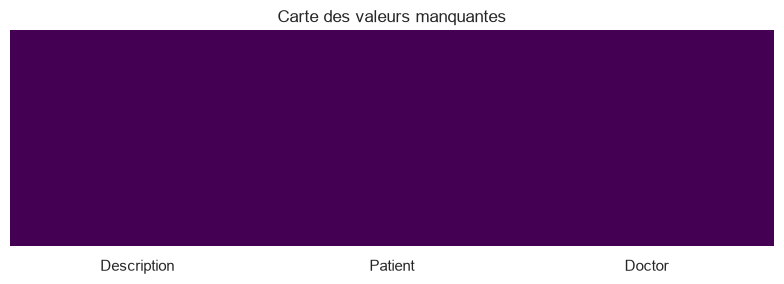

In [4]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulls': null_counts, '% manquant': null_pct})
print(null_df)

# Heatmap
plt.figure(figsize=(8, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Carte des valeurs manquantes')
plt.tight_layout()
plt.show()

## 5. Doublons

In [5]:
dupes = df.duplicated(subset=['Patient', 'Doctor'], keep=False)
print(f'Doublons exacts (Patient + Doctor) : {dupes.sum():,} lignes ({dupes.mean()*100:.2f}%)')

if dupes.sum() > 0:
    print('\nExemples de doublons :')
    display(df[dupes].head(4)[['Patient', 'Doctor']])

Doublons exacts (Patient + Doctor) : 10,436 lignes (4.06%)

Exemples de doublons :


,Patient,Doctor
0,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
1,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...
8,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
9,"Hello doctor, I am 48 years old. I am experien...",Hi. For further doubts consult a sexologist on...


## 6. Distribution des longueurs — Patient

=== Patient — longueur en caractères ===
count    256916.0
mean        436.5
std         299.4
min           1.0
5%          238.0
25%         283.0
75%         491.0
95%         899.0
max       17735.0
Name: patient_len, dtype: float64


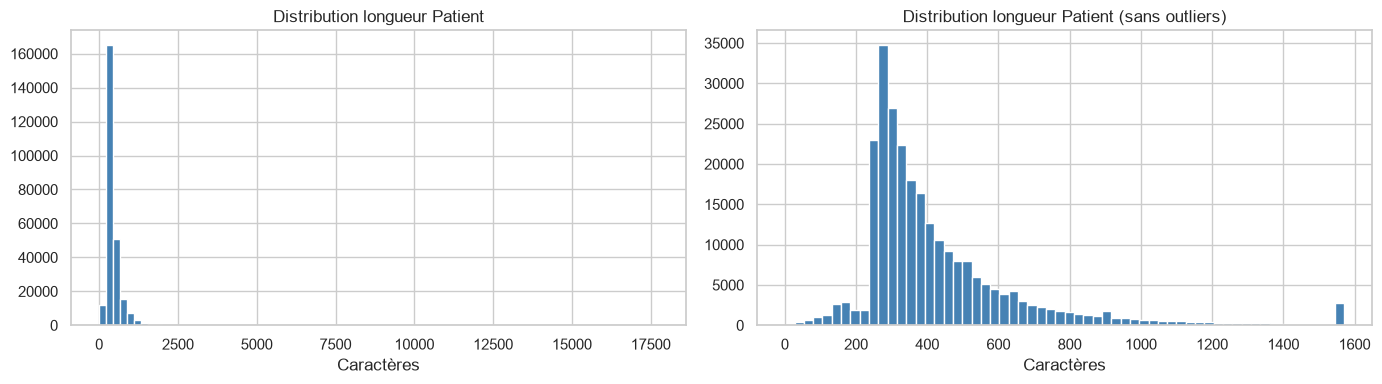

In [6]:
df['patient_len'] = df['Patient'].fillna('').str.len()

print('=== Patient — longueur en caractères ===')
print(df['patient_len'].describe(percentiles=[.05, .25, .75, .95]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['patient_len'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution longueur Patient')
axes[0].set_xlabel('Caractères')

axes[1].hist(df['patient_len'].clip(upper=df['patient_len'].quantile(0.99)), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution longueur Patient (sans outliers)')
axes[1].set_xlabel('Caractères')

plt.tight_layout()
plt.show()

## 7. Distribution des longueurs — Doctor

=== Doctor — longueur en caractères ===
count    256916.0
mean        537.4
std         338.7
min           2.0
5%          147.0
25%         318.0
75%         675.0
95%        1129.0
max       11385.0
Name: doctor_len, dtype: float64


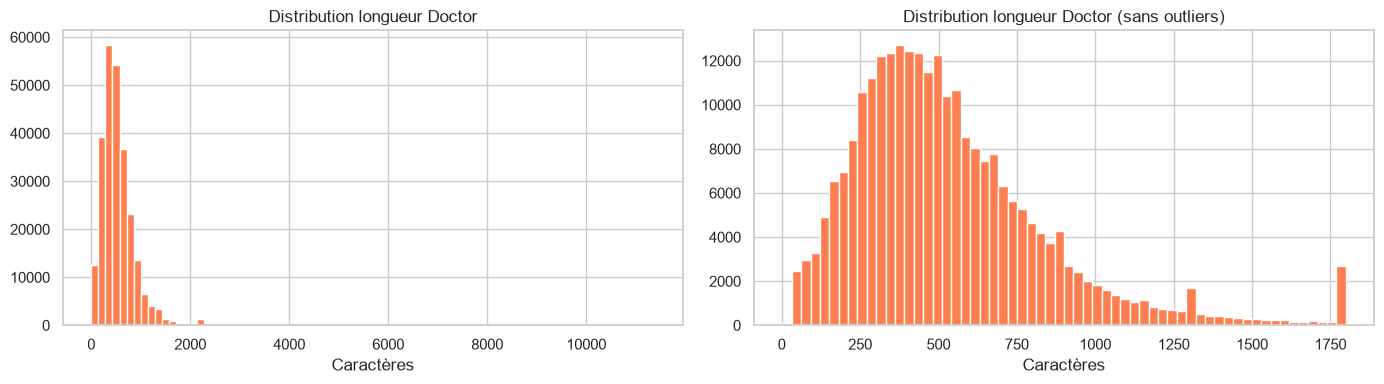

In [7]:
df['doctor_len'] = df['Doctor'].fillna('').str.len()

print('=== Doctor — longueur en caractères ===')
print(df['doctor_len'].describe(percentiles=[.05, .25, .75, .95]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['doctor_len'], bins=80, color='coral', edgecolor='white')
axes[0].set_title('Distribution longueur Doctor')
axes[0].set_xlabel('Caractères')

axes[1].hist(df['doctor_len'].clip(upper=df['doctor_len'].quantile(0.99)), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribution longueur Doctor (sans outliers)')
axes[1].set_xlabel('Caractères')

plt.tight_layout()
plt.show()

## 8. Réponses extrêmes

In [8]:
short_patient = df[df['patient_len'] < 10]
short_doctor  = df[df['doctor_len']  < 20]
long_patient  = df[df['patient_len'] > 1000]
long_doctor   = df[df['doctor_len']  > 2000]

print(f'Patient trop court  (< 10 chars)  : {len(short_patient):,}')
print(f'Doctor trop court   (< 20 chars)  : {len(short_doctor):,}')
print(f'Patient trop long   (> 1000 chars): {len(long_patient):,}')
print(f'Doctor trop long    (> 2000 chars): {len(long_doctor):,}')

print('\n--- Exemples Doctor trop court ---')
display(short_doctor[['Patient', 'Doctor']].head(5))

print('\n--- Exemples Doctor trop long ---')
display(long_doctor[['Patient', 'Doctor']].head(3))

Patient trop court  (< 10 chars)  : 26
Doctor trop court   (< 20 chars)  : 55
Patient trop long   (> 1000 chars): 9,401
Doctor trop long    (> 2000 chars): 2,045

--- Exemples Doctor trop court ---


,Patient,Doctor
2894,"Hi doctor, Around 15 years ago, I had Redux fo...",Hi.
3952,"Hello doctor, I want to know about the Unwante...",Hello.
4071,"Hi doctor, I had irregular periods. All my oth...",Hello.
8670,"Dear Doctor, I have attached images of the lat...",Hi. Hope it helps.
17550,"Hi doctor, I had flipped the condom before hav...",Hi.



--- Exemples Doctor trop long ---


,Patient,Doctor
255,"Hi doctor, I would like to get a summary of ab...",Hello. For someone who is 6 weeks or 42 days p...
281,"Hello doctor, Thank you for giving us the firs...",Hello. Regarding the continuation of medicines...
383,"Hello doctor,My 5 years old girl has been havi...",Hello. You have put your query with nice descr...


## 9. Top 20 mots fréquents

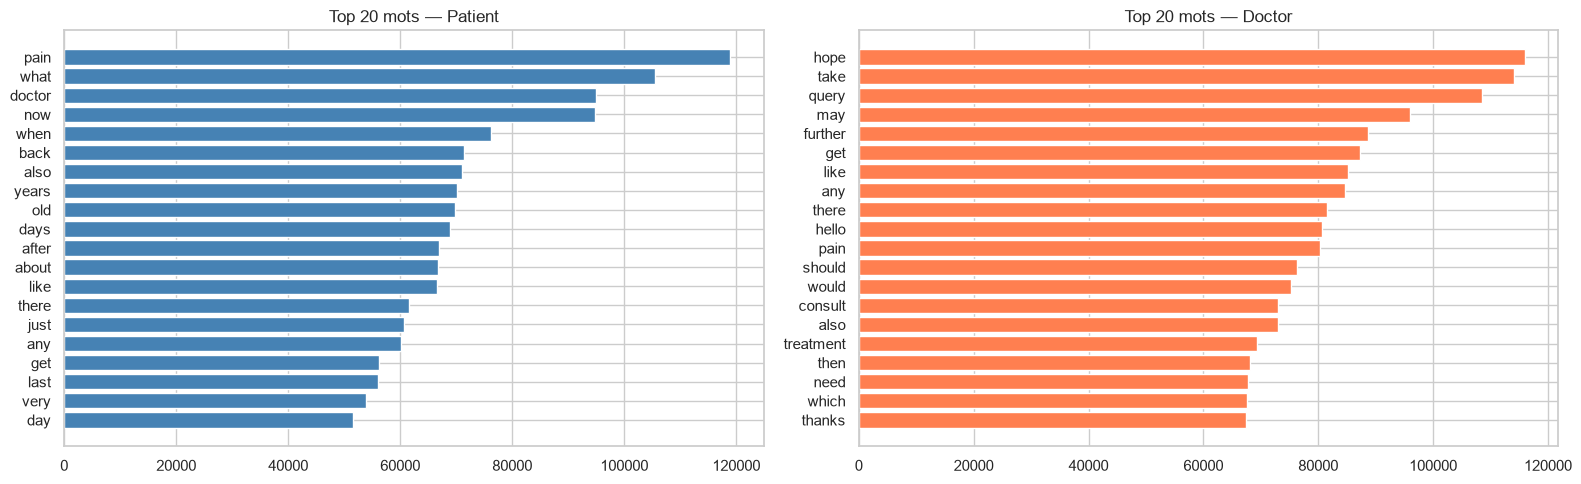

In [9]:
STOPWORDS = {'i', 'the', 'a', 'and', 'is', 'in', 'to', 'of', 'it', 'my',
             'me', 'for', 'you', 'have', 'am', 'been', 'was', 'are', 'be',
             'with', 'this', 'that', 'your', 'or', 'on', 'at', 'as', 'by',
             'an', 'do', 'not', 'can', 'he', 'she', 'they', 'we', 'but',
             'has', 'had', 'no', 'so', 'if', 'from', 'his', 'her', 'will'}

def top_words(series, n=20):
    tokens = re.findall(r'\b[a-z]{3,}\b', ' '.join(series.dropna().str.lower()))
    return Counter(t for t in tokens if t not in STOPWORDS).most_common(n)

top_p = top_words(df['Patient'])
top_d = top_words(df['Doctor'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words_p, counts_p = zip(*top_p)
axes[0].barh(words_p[::-1], counts_p[::-1], color='steelblue')
axes[0].set_title('Top 20 mots — Patient')

words_d, counts_d = zip(*top_d)
axes[1].barh(words_d[::-1], counts_d[::-1], color='coral')
axes[1].set_title('Top 20 mots — Doctor')

plt.tight_layout()
plt.show()

## 10. Synthèse & recommandations

**Observations à compléter après exécution :**

- Nombre total de lignes : *à noter*
- % valeurs manquantes Patient / Doctor : *à noter*
- % doublons exacts : *à noter*
- Longueur médiane Patient / Doctor : *à noter*
- Lignes filtrées si seuils : Patient [10–1000 chars], Doctor [20–2000 chars]

**Seuils recommandés pour `02_clean.ipynb` :**

| Colonne | Min | Max |
|---------|-----|-----|
| Patient | 10  | 1000 |
| Doctor  | 20  | 2000 |

Ajuster si les distributions observées le justifient.